<a href="https://colab.research.google.com/github/guruvemula61-cmyk/q-schedule-qaoa/blob/main/Q_Schedule_QAOA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q qiskit qiskit-aer qiskit-algorithms qiskit-optimization qiskit-ibm-runtime networkx pandas plotly matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 11.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.3/113.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.0 MB/s eta 0

In [2]:
import qiskit, qiskit_aer, qiskit_optimization
print("Qiskit version:", qiskit.__version__)
print("Aer version:", qiskit_aer.__version__)

Qiskit version: 2.5.2
Aer version: 0.17.2


   student_id      subject
0           1  Electronics
1           1    Economics
2           2      History
3           2        Maths
4           3        Maths 
Total rows: 75
Nodes: 10 Edges: 34


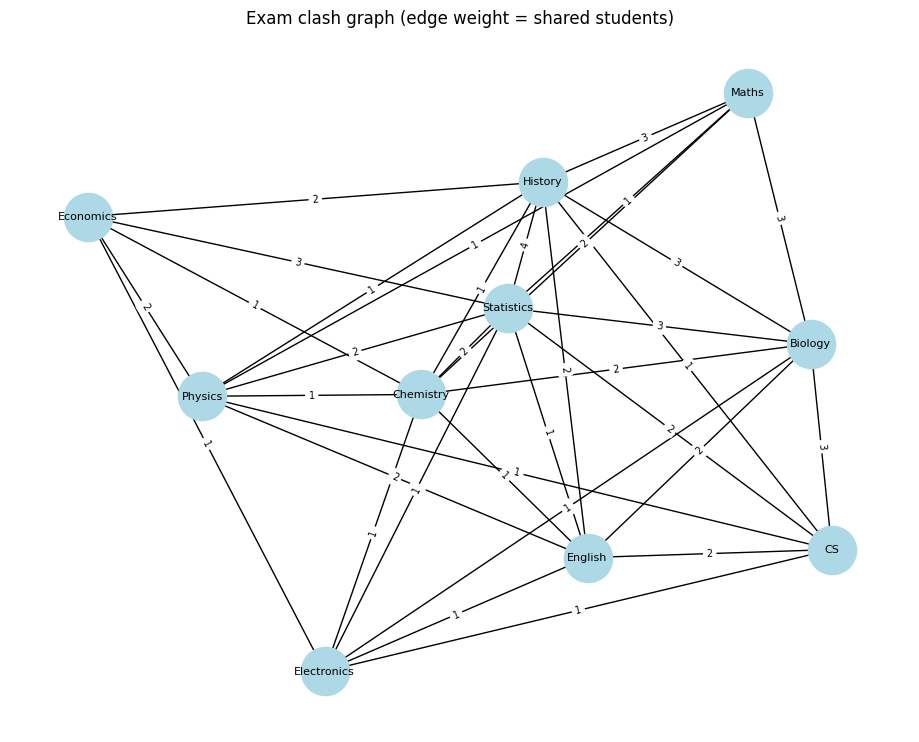

In [3]:
import numpy as np, pandas as pd, networkx as nx, matplotlib.pyplot as plt
from itertools import combinations

# 1. Synthetic enrollment data (10 subjects, 30 students)
rng = np.random.default_rng(42)
subjects = ["Maths","Physics","Chemistry","CS","English",
            "Biology","Economics","History","Statistics","Electronics"]
rows = []
for sid in range(1, 31):
    n = int(rng.integers(2, 4))          # each student takes 2 or 3 subjects
    for s in rng.choice(subjects, size=n, replace=False):
        rows.append((sid, str(s)))
df = pd.DataFrame(rows, columns=["student_id", "subject"])
df.to_csv("enrollment.csv", index=False)
print(df.head(), "\nTotal rows:", len(df))

# 2. Weighted clash graph (edge weight = students common to both subjects)
G = nx.Graph()
G.add_nodes_from(subjects)
for sid, group in df.groupby("student_id"):
    for a, b in combinations(sorted(group["subject"]), 2):
        if G.has_edge(a, b):
            G[a][b]["weight"] += 1
        else:
            G.add_edge(a, b, weight=1)
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

# 3. Draw the graph
pos = nx.spring_layout(G, seed=1)
plt.figure(figsize=(9, 7))
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=1200, font_size=8)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"), font_size=7)
plt.title("Exam clash graph (edge weight = shared students)")
plt.show()

In [4]:
import time
from qiskit_optimization.applications import Maxcut

# 1. Subject names ni 0..9 numbers ga map cheyyadam (qubit i = subject i)
names = list(G.nodes())
idx = {s: i for i, s in enumerate(names)}
H = nx.relabel_nodes(G, idx)
n = len(names)

# 2. Max-Cut -> QuadraticProgram -> Ising Hamiltonian
maxcut = Maxcut(H)
qp = maxcut.to_quadratic_program()
op, offset = qp.to_ising()
print("Qubits:", op.num_qubits)
print("Ising terms:", len(op))
print("Offset:", offset)

# 3. Brute force: anni 2^10 = 1024 timetables check cheyyadam
W = nx.to_numpy_array(H, nodelist=range(n))
total_weight = W.sum() / 2

def cut_value(bits):
    return sum(W[i][j] for i in range(n) for j in range(i + 1, n) if bits[i] != bits[j])

t0 = time.time()
best_cut, best_bits = -1, []
for k in range(2 ** n):
    bits = [(k >> i) & 1 for i in range(n)]
    c = cut_value(bits)
    if c > best_cut:
        best_cut, best_bits = c, [bits]
    elif c == best_cut:
        best_bits.append(bits)
bf_time = time.time() - t0

print("\nTotal student-overlap weight:", total_weight)
print("Optimal cut value:", best_cut)
print("Minimum remaining clashes:", total_weight - best_cut)
print("Number of optimal bitstrings:", len(best_bits), "(complement pairs valtha even untundi)")
print("Brute-force runtime: %.3f s" % bf_time)
print("One optimal timetable:", {names[i]: f"Slot {b}" for i, b in enumerate(best_bits[0])})

Qubits: 10
Ising terms: 34
Offset: -30.0

Total student-overlap weight: 60.0
Optimal cut value: 41.0
Minimum remaining clashes: 19.0
Number of optimal bitstrings: 2 (complement pairs valtha even untundi)
Brute-force runtime: 0.031 s
One optimal timetable: {'Maths': 'Slot 1', 'Physics': 'Slot 0', 'Chemistry': 'Slot 0', 'CS': 'Slot 1', 'English': 'Slot 1', 'Biology': 'Slot 0', 'Economics': 'Slot 1', 'History': 'Slot 0', 'Statistics': 'Slot 1', 'Electronics': 'Slot 0'}


 p top_bitstring  cut_top  clashes_top  approx_ratio_top  avg_cut  approx_ratio_avg  P(optimal)  runtime_s
 1    0010101110     39.0         21.0             0.951   30.533             0.745       0.000      5.784
 2    1010100110     41.0         19.0             1.000   35.257             0.860       0.022      4.093
 3    1010100110     41.0         19.0             1.000   35.915             0.876       0.028      3.788


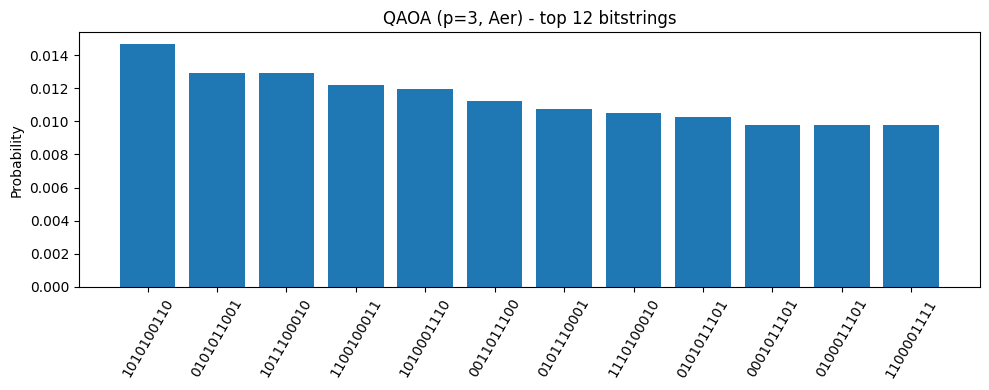

In [5]:
from qiskit import transpile
from qiskit.circuit.library import QAOAAnsatz
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2
from scipy.optimize import minimize
from collections import Counter

backend = AerSimulator()
estimator = EstimatorV2()
SHOTS = 4096

def decode(bitstring):
    # Qiskit little-endian: rightmost char = qubit 0, kabatti reverse chestunnam
    return [int(c) for c in bitstring[::-1]]

def run_qaoa(p, seed=0):
    ansatz = QAOAAnsatz(cost_operator=op, reps=p)
    ansatz_t = transpile(ansatz, backend, optimization_level=1)
    rng = np.random.default_rng(seed)
    x0 = rng.uniform(0, np.pi, 2 * p)

    def cost(params):
        evs = estimator.run([(ansatz_t, op, params)]).result()[0].data.evs
        return float(evs) + offset          # = -(expected cut)

    t0 = time.time()
    res = minimize(cost, x0, method="COBYLA", options={"maxiter": 150})
    qaoa_time = time.time() - t0

    # Optimized circuit ni sample cheyyadam
    qc = transpile(ansatz.assign_parameters(res.x), backend, optimization_level=1)
    qc.measure_all()
    counts = backend.run(qc, shots=SHOTS, seed_simulator=seed).result().get_counts()

    cut_of = {s: cut_value(decode(s)) for s in counts}
    top = max(counts, key=counts.get)
    p_opt = sum(c for s, c in counts.items() if cut_of[s] == best_cut) / SHOTS
    exp_cut = sum(counts[s] * cut_of[s] for s in counts) / SHOTS
    return {
        "p": p,
        "top_bitstring": top,
        "cut_top": cut_of[top],
        "clashes_top": total_weight - cut_of[top],
        "approx_ratio_top": cut_of[top] / best_cut,
        "avg_cut": exp_cut,
        "approx_ratio_avg": exp_cut / best_cut,
        "P(optimal)": p_opt,
        "runtime_s": qaoa_time,
        "counts": counts,
        "params": res.x,
    }

results = [run_qaoa(p) for p in (1, 2, 3)]

table = pd.DataFrame([{k: v for k, v in r.items() if k not in ("counts", "params")} for r in results])
print(table.round(3).to_string(index=False))

# p=3 histogram (top 12 bitstrings)
top12 = Counter(results[-1]["counts"]).most_common(12)
plt.figure(figsize=(10, 4))
plt.bar([s for s, _ in top12], [c / SHOTS for _, c in top12])
plt.xticks(rotation=60); plt.ylabel("Probability")
plt.title("QAOA (p=3, Aer) - top 12 bitstrings")
plt.tight_layout(); plt.show()

                 Method  Cut  Runtime_s  Clashes  Approx_ratio
      Random (expected) 30.0      0.000     30.0         0.732
  Greedy (degree-first) 40.0      0.009     20.0         0.976
         QAOA p=1 (Aer) 39.0      5.784     21.0         0.951
         QAOA p=2 (Aer) 41.0      4.093     19.0         1.000
         QAOA p=3 (Aer) 41.0      3.788     19.0         1.000
QAOA p=3 best of top-10 41.0      3.788     19.0         1.000
  Brute force (optimal) 41.0      0.031     19.0         1.000


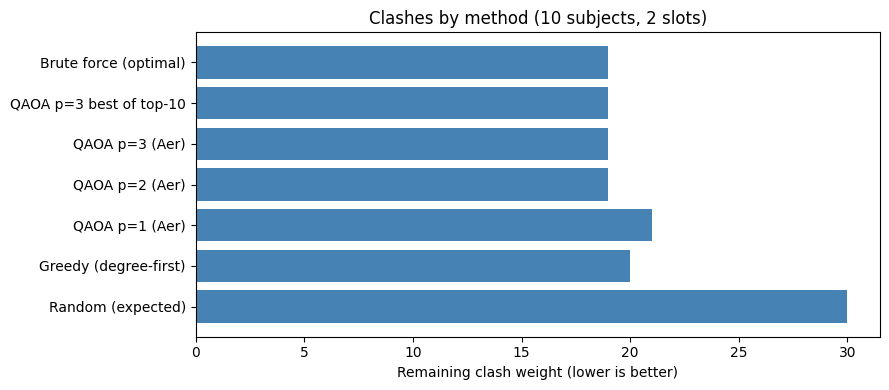

In [6]:
# Greedy: largest weighted-degree first, prathi subject ni takkuva clash vache slot ki pettadam
def greedy_schedule():
    t0 = time.time()
    order = np.argsort(-W.sum(axis=1))
    slot = {}
    for v in order:
        c0 = sum(W[v][u] for u in slot if slot[u] == 0)
        c1 = sum(W[v][u] for u in slot if slot[u] == 1)
        slot[v] = 0 if c0 <= c1 else 1
    bits = [slot[i] for i in range(n)]
    return bits, time.time() - t0

g_bits, g_time = greedy_schedule()
g_cut = cut_value(g_bits)

# Best-of-top-10 QAOA bitstrings (p=3)
top10 = Counter(results[-1]["counts"]).most_common(10)
best_top10_cut = max(cut_value(decode(s)) for s, _ in top10)

rows = [
    {"Method": "Random (expected)", "Cut": total_weight / 2, "Runtime_s": 0.0},
    {"Method": "Greedy (degree-first)", "Cut": g_cut, "Runtime_s": g_time},
    {"Method": "QAOA p=1 (Aer)", "Cut": results[0]["cut_top"], "Runtime_s": results[0]["runtime_s"]},
    {"Method": "QAOA p=2 (Aer)", "Cut": results[1]["cut_top"], "Runtime_s": results[1]["runtime_s"]},
    {"Method": "QAOA p=3 (Aer)", "Cut": results[2]["cut_top"], "Runtime_s": results[2]["runtime_s"]},
    {"Method": "QAOA p=3 best of top-10", "Cut": best_top10_cut, "Runtime_s": results[2]["runtime_s"]},
    {"Method": "Brute force (optimal)", "Cut": best_cut, "Runtime_s": bf_time},
]
bench = pd.DataFrame(rows)
bench["Clashes"] = total_weight - bench["Cut"]
bench["Approx_ratio"] = bench["Cut"] / best_cut
print(bench.round(3).to_string(index=False))

import os
os.makedirs("results", exist_ok=True)
bench.round(3).to_csv("results/benchmark_table.csv", index=False)

# Chart: remaining clashes
plt.figure(figsize=(9, 4))
plt.barh(bench["Method"], bench["Clashes"], color="steelblue")
plt.xlabel("Remaining clash weight (lower is better)")
plt.title("Clashes by method (10 subjects, 2 slots)")
plt.tight_layout(); plt.show()